# 08 - Final Report and Kaggle Notebook

**Phase:** 8
**Purpose:** consolidate the revised ModernBERT raw-feature + sequence-track pipeline into a submission-ready notebook and report.

The report must explicitly show where ModernBERT is used, why CNN-BiLSTM is evaluated on sequence input, and how balanced vs precision-first winners were selected.


## How to run on Colab

Run the project notebooks in this order:

1. `01_EDA_Preprocessing.ipynb`
2. `02_Feature_Engineering.ipynb`
3. `03_PCA_Feature_Selection.ipynb` only when PCA/SVD diagnostic artifacts need refresh
4. `04_PSO_Model_Training.ipynb` only when legacy PSO/PCA ablation needs refresh
5. Phase 5 notebook family: `05_00` through `05_06`, then `05_Hybrid_Ensemble.ipynb`
6. `06_Adversarial_XAI.ipynb`
7. `07_Evaluation_Ablation.ipynb`
8. `08_Final_Report_Kaggle.ipynb`


In [1]:
# try/except: khối xử lý ngoại lệ
try:
    # import google.colab  # type: ignore: import thư viện google
    import google.colab  # type: ignore
    # IN_COLAB: biến cấu hình/hằng số của notebook
    IN_COLAB = True
# except: xử lý ngoại lệ — except Exception:
except Exception:
    # IN_COLAB: biến cấu hình/hằng số của notebook
    IN_COLAB = False

# if: điều kiện — if not IN_COLAB:
if not IN_COLAB:
    # raise RuntimeError('Run this notebook in Google Colab unless local execution is ...: ném lỗi và dừng cell
    raise RuntimeError('Run this notebook in Google Colab unless local execution is explicitly approved.')


In [2]:
# from google.colab import drive: import thư viện google
from google.colab import drive
# drive.mount('/content/drive'): mount Google Drive trên Colab
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
# import json: đọc/ghi JSON metadata
import json
# from datetime import datetime, timezone: import thư viện datetime
from datetime import datetime, timezone
# from pathlib import Path: quản lý đường dẫn
from pathlib import Path

# import numpy: tính toán mảng số
import numpy as np
# import pandas: xử lý DataFrame
import pandas as pd
# from IPython.display import Image, Markdown, display: import thư viện IPython
from IPython.display import Image, Markdown, display

# SEED: biến cấu hình/hằng số của notebook
SEED = 42
# ROOT_CANDIDATES: biến cấu hình/hằng số của notebook
ROOT_CANDIDATES = [
    # Path('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews'),: thực thi lệnh Python
    Path('/content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews'),
    # Path('/content/drive/MyDrive/Fake_reviews'),: thực thi lệnh Python
    Path('/content/drive/MyDrive/Fake_reviews'),
# ]: đóng khối danh sách
]
# PROJECT_ROOT: biến cấu hình/hằng số của notebook
PROJECT_ROOT = next((path for path in ROOT_CANDIDATES if path.exists()), ROOT_CANDIDATES[0])
# DATA_DIR: biến cấu hình/hằng số của notebook
DATA_DIR = PROJECT_ROOT / 'data'
# PROCESSED_DIR: biến cấu hình/hằng số của notebook
PROCESSED_DIR = DATA_DIR / 'processed'
# ARTIFACT_DIR: biến cấu hình/hằng số của notebook
ARTIFACT_DIR = PROJECT_ROOT / 'artifacts'
# FEATURE_DIR: biến cấu hình/hằng số của notebook
FEATURE_DIR = ARTIFACT_DIR / 'features'
# PCA_DIR: biến cấu hình/hằng số của notebook
PCA_DIR = ARTIFACT_DIR / 'pca'
# MODEL_DIR: biến cấu hình/hằng số của notebook
MODEL_DIR = ARTIFACT_DIR / 'models'
# ENSEMBLE_DIR: biến cấu hình/hằng số của notebook
ENSEMBLE_DIR = ARTIFACT_DIR / 'ensemble'
# PREDICTION_DIR: biến cấu hình/hằng số của notebook
PREDICTION_DIR = ARTIFACT_DIR / 'predictions'
# EVALUATION_DIR: biến cấu hình/hằng số của notebook
EVALUATION_DIR = ARTIFACT_DIR / 'evaluation'
# XAI_DIR: biến cấu hình/hằng số của notebook
XAI_DIR = ARTIFACT_DIR / 'xai'
# REPORT_DIR: biến cấu hình/hằng số của notebook
REPORT_DIR = PROJECT_ROOT / 'reports'
# TABLE_DIR: biến cấu hình/hằng số của notebook
TABLE_DIR = REPORT_DIR / 'tables'
# FIGURE_DIR: biến cấu hình/hằng số của notebook
FIGURE_DIR = REPORT_DIR / 'figures'
# FINAL_DIR: biến cấu hình/hằng số của notebook
FINAL_DIR = REPORT_DIR / 'final'
# FINAL_DIR.mkdir(parents=True, exist_ok=True): tạo thư mục nếu chưa có
FINAL_DIR.mkdir(parents=True, exist_ok=True)
# print(f'PROJECT_ROOT = {PROJECT_ROOT}'): in thông tin ra console
print(f'PROJECT_ROOT = {PROJECT_ROOT}')
# print(f'FINAL_DIR = {FINAL_DIR}'): in thông tin ra console
print(f'FINAL_DIR = {FINAL_DIR}')


PROJECT_ROOT = /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews
FINAL_DIR = /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/final


In [4]:
# read_json: đọc file JSON
def read_json(path: Path, default=None):
    # if: điều kiện — if path.exists():
    if path.exists():
        # with: context manager — with path.open('r', encoding='utf-8') as f:
        with path.open('r', encoding='utf-8') as f:
            # return: parse nội dung JSON
            return json.load(f)
    # return: trả kết quả từ hàm
    return {} if default is None else default


# read_csv: hàm xử lý read csv
def read_csv(path: Path, required: bool = True) -> pd.DataFrame:
    # if: điều kiện — if path.exists():
    if path.exists():
        # return: đọc file CSV vào DataFrame
        return pd.read_csv(path)
    # if: điều kiện — if required:
    if required:
        # raise FileNotFoundError(f'Missing required report table: {path}'): ném lỗi và dừng cell
        raise FileNotFoundError(f'Missing required report table: {path}')
    # return: trả kết quả từ hàm
    return pd.DataFrame()


# fmt: hàm xử lý fmt
def fmt(value, digits: int = 6) -> str:
    # if: điều kiện — if pd.isna(value):
    if pd.isna(value):
        # return: trả kết quả từ hàm
        return 'NA'
    # try/except: khối xử lý ngoại lệ
    try:
        # return: trả kết quả từ hàm
        return f'{float(value):.{digits}f}'
    # except: xử lý ngoại lệ — except Exception:
    except Exception:
        # return: trả kết quả từ hàm
        return str(value)


# artifact_row: hàm xử lý artifact row
def artifact_row(phase, group, rel_path, required=True, note=''):
    # path = ...: gán giá trị cho biến path
    path = PROJECT_ROOT / rel_path
    # return: trả kết quả từ hàm
    return {
        # 'phase': phase,: thực thi lệnh Python
        'phase': phase,
        # 'artifact_group': group,: thực thi lệnh Python
        'artifact_group': group,
        # 'path': str(path),: ép kiểu chuỗi
        'path': str(path),
        # 'required': bool(required),: ép kiểu boolean
        'required': bool(required),
        # 'exists': path.exists(),: kiểm tra file/thư mục tồn tại
        'exists': path.exists(),
        # 'file_size_bytes': path.stat().st_size if path.exists() and path.is_file() else ...: kiểm tra file/thư mục tồn tại
        'file_size_bytes': path.stat().st_size if path.exists() and path.is_file() else '',
        # 'note': note,: thực thi lệnh Python
        'note': note,
    # }: đóng khối từ điển
    }


## Artifact inventory

The inventory makes the delivery folder auditable. Required missing files should be fixed by rerunning the corresponding prior Colab phase before using this notebook as a final submission.


In [5]:
# artifact_specs = ...: gán giá trị cho biến artifact specs
artifact_specs = [
    # (1, 'raw_dataset', 'data/final_labeled_fake_reviews.csv', True, 'Original datase...: tạo tập hợp
    (1, 'raw_dataset', 'data/final_labeled_fake_reviews.csv', True, 'Original dataset. Do not rewrite.'),
    # (1, 'processed_split', 'data/processed/clean_reviews.csv', True, 'Cleaned datase...: tạo tập hợp
    (1, 'processed_split', 'data/processed/clean_reviews.csv', True, 'Cleaned dataset from Phase 1.'),
    # (1, 'processed_split', 'data/processed/train.csv', True, 'Train split.'),: thực thi lệnh Python
    (1, 'processed_split', 'data/processed/train.csv', True, 'Train split.'),
    # (1, 'processed_split', 'data/processed/val.csv', True, 'Validation split.'),: thực thi lệnh Python
    (1, 'processed_split', 'data/processed/val.csv', True, 'Validation split.'),
    # (1, 'processed_split', 'data/processed/test.csv', True, 'Test split.'),: thực thi lệnh Python
    (1, 'processed_split', 'data/processed/test.csv', True, 'Test split.'),
    # (2, 'features', 'artifacts/features/feature_metadata.json', True, 'ModernBERT an...: thực thi lệnh Python
    (2, 'features', 'artifacts/features/feature_metadata.json', True, 'ModernBERT and behavioral feature metadata.'),
    # (2, 'features', 'artifacts/features/feature_dictionary.csv', True, 'Feature dict...: tạo dictionary
    (2, 'features', 'artifacts/features/feature_dictionary.csv', True, 'Feature dictionary.'),
    # (2, 'features', 'artifacts/features/features_raw_train.npy', True, 'Raw fused tr...: thực thi lệnh Python
    (2, 'features', 'artifacts/features/features_raw_train.npy', True, 'Raw fused train features.'),
    # (2, 'features', 'artifacts/features/features_raw_val.npy', True, 'Raw fused vali...: thực thi lệnh Python
    (2, 'features', 'artifacts/features/features_raw_val.npy', True, 'Raw fused validation features.'),
    # (2, 'features', 'artifacts/features/features_raw_test.npy', True, 'Raw fused tes...: thực thi lệnh Python
    (2, 'features', 'artifacts/features/features_raw_test.npy', True, 'Raw fused test features.'),
    # (3, 'pca', 'artifacts/pca/pca_or_svd.joblib', True, 'Train-fitted PCA/SVD object...: fit model/reducer trên dữ liệu train
    (3, 'pca', 'artifacts/pca/pca_or_svd.joblib', True, 'Train-fitted PCA/SVD object.'),
    # (3, 'pca', 'artifacts/pca/pca_scaler.joblib', True, 'Train-fitted scaler.'),: fit model/reducer trên dữ liệu train
    (3, 'pca', 'artifacts/pca/pca_scaler.joblib', True, 'Train-fitted scaler.'),
    # (3, 'pca', 'artifacts/pca/features_final_train.npy', True, 'Reduced train featur...: thực thi lệnh Python
    (3, 'pca', 'artifacts/pca/features_final_train.npy', True, 'Reduced train features.'),
    # (3, 'pca', 'artifacts/pca/features_final_val.npy', True, 'Reduced validation fea...: thực thi lệnh Python
    (3, 'pca', 'artifacts/pca/features_final_val.npy', True, 'Reduced validation features.'),
    # (3, 'pca', 'artifacts/pca/features_final_test.npy', True, 'Reduced test features...: thực thi lệnh Python
    (3, 'pca', 'artifacts/pca/features_final_test.npy', True, 'Reduced test features.'),
    # (4, 'deep_model', 'artifacts/models/best_model_dl.pth', True, 'Best PSO-tuned DL...: ép kiểu số nguyên
    (4, 'deep_model', 'artifacts/models/best_model_dl.pth', True, 'Best PSO-tuned DL checkpoint.'),
    # (4, 'deep_model', 'artifacts/models/best_params.json', True, 'Best PSO parameter...: thực thi lệnh Python
    (4, 'deep_model', 'artifacts/models/best_params.json', True, 'Best PSO parameters.'),
    # (4, 'deep_model', 'artifacts/models/phase4_metadata.json', True, 'Phase 4 metada...: thực thi lệnh Python
    (4, 'deep_model', 'artifacts/models/phase4_metadata.json', True, 'Phase 4 metadata.'),
    # (5, 'ensemble', 'artifacts/ensemble/final_ensemble_model.pkl', True, 'Final ense...: thực thi lệnh Python
    (5, 'ensemble', 'artifacts/ensemble/final_ensemble_model.pkl', True, 'Final ensemble artifact.'),
    # (5, 'ensemble', 'artifacts/ensemble/xgboost_model.pkl', True, 'XGBoost model art...: xóa biến để giải phóng RAM/VRAM
    (5, 'ensemble', 'artifacts/ensemble/xgboost_model.pkl', True, 'XGBoost model artifact.'),
    # (5, 'ensemble', 'artifacts/ensemble/lightgbm_model.pkl', True, 'LightGBM model a...: xóa biến để giải phóng RAM/VRAM
    (5, 'ensemble', 'artifacts/ensemble/lightgbm_model.pkl', True, 'LightGBM model artifact.'),
    # (5, 'ensemble', 'artifacts/ensemble/stacking_meta_model.pkl', True, 'Stacking me...: xóa biến để giải phóng RAM/VRAM
    (5, 'ensemble', 'artifacts/ensemble/stacking_meta_model.pkl', True, 'Stacking meta-model artifact.'),
    # (5, 'ensemble', 'artifacts/ensemble/probability_calibrator.pkl', False, 'Calibra...: ép kiểu chuỗi
    (5, 'ensemble', 'artifacts/ensemble/probability_calibrator.pkl', False, 'Calibration object when selected strategy uses it.'),
    # (5, 'ensemble', 'artifacts/ensemble/phase5_metadata.json', True, 'Phase 5 metada...: thực thi lệnh Python
    (5, 'ensemble', 'artifacts/ensemble/phase5_metadata.json', True, 'Phase 5 metadata.'),
    # (5, 'tables', 'reports/tables/phase5_leaderboard.csv', True, 'Phase 5 leaderboar...: thực thi lệnh Python
    (5, 'tables', 'reports/tables/phase5_leaderboard.csv', True, 'Phase 5 leaderboard (2026-06).'),
    # (5, 'tables', 'reports/tables/literature_sota_comparison.csv', True, 'Literature...: thực thi lệnh Python
    (5, 'tables', 'reports/tables/literature_sota_comparison.csv', True, 'Literature SOTA comparison table.'),
    # (5, 'tables', 'reports/tables/literature_references_20.csv', True, '20 verified ...: thực thi lệnh Python
    (5, 'tables', 'reports/tables/literature_references_20.csv', True, '20 verified references.'),
    # (5, 'tables', 'reports/tables/phase5_selected_candidates_test_audit.csv', False,...: thực thi lệnh Python
    (5, 'tables', 'reports/tables/phase5_selected_candidates_test_audit.csv', False, 'Phase 5 test audit (after 05_Hybrid rerun).'),
    # (6, 'robustness_xai', 'artifacts/xai/phase6_metadata.json', True, 'Robustness an...: thực thi lệnh Python
    (6, 'robustness_xai', 'artifacts/xai/phase6_metadata.json', True, 'Robustness and XAI metadata.'),
    # (6, 'robustness_xai', 'reports/tables/phase6_robustness_metrics.csv', True, 'Rob...: thực thi lệnh Python
    (6, 'robustness_xai', 'reports/tables/phase6_robustness_metrics.csv', True, 'Robustness metrics.'),
    # (6, 'robustness_xai', 'reports/tables/phase6_shap_global_importance.csv', True, ...: thực thi lệnh Python
    (6, 'robustness_xai', 'reports/tables/phase6_shap_global_importance.csv', True, 'SHAP global importance.'),
    # (6, 'robustness_xai', 'reports/tables/phase6_lime_case_summary.csv', True, 'LIME...: tính tổng
    (6, 'robustness_xai', 'reports/tables/phase6_lime_case_summary.csv', True, 'LIME case summary.'),
    # (7, 'evaluation', 'reports/tables/phase7_final_metrics.csv', True, 'Final metric...: thực thi lệnh Python
    (7, 'evaluation', 'reports/tables/phase7_final_metrics.csv', True, 'Final metrics.'),
    # (7, 'evaluation', 'reports/tables/phase7_target_audit.csv', True, 'Target audit....: thực thi lệnh Python
    (7, 'evaluation', 'reports/tables/phase7_target_audit.csv', True, 'Target audit.'),
    # (7, 'evaluation', 'reports/tables/phase7_cv_summary.csv', True, 'CV summary.'),: tính tổng
    (7, 'evaluation', 'reports/tables/phase7_cv_summary.csv', True, 'CV summary.'),
    # (7, 'evaluation', 'reports/tables/phase7_ablation_results.csv', True, 'Ablation ...: thực thi lệnh Python
    (7, 'evaluation', 'reports/tables/phase7_ablation_results.csv', True, 'Ablation results.'),
    # (7, 'evaluation', 'reports/tables/phase7_ablation_delta.csv', True, 'Ablation de...: thực thi lệnh Python
    (7, 'evaluation', 'reports/tables/phase7_ablation_delta.csv', True, 'Ablation deltas.'),
    # (7, 'evaluation', 'reports/tables/phase7_error_analysis.csv', True, 'Error analy...: thực thi lệnh Python
    (7, 'evaluation', 'reports/tables/phase7_error_analysis.csv', True, 'Error analysis.'),
    # (7, 'evaluation', 'artifacts/evaluation/phase7_metadata.json', True, 'Evaluation...: thực thi lệnh Python
    (7, 'evaluation', 'artifacts/evaluation/phase7_metadata.json', True, 'Evaluation metadata.'),
# ]: đóng khối danh sách
]
# artifact_inventory = ...: gán giá trị cho biến artifact inventory
artifact_inventory = pd.DataFrame([artifact_row(*spec) for spec in artifact_specs])
# artifact_inventory.to_csv(FINAL_DIR / 'phase8_artifact_inventory.csv', index=Fal...: ghi DataFrame ra file CSV
artifact_inventory.to_csv(FINAL_DIR / 'phase8_artifact_inventory.csv', index=False)
# display(artifact_inventory): hiển thị bảng/kết quả trên notebook
display(artifact_inventory)
# required_missing = ...: kiểm tra file/thư mục tồn tại
required_missing = artifact_inventory.query('required == True and exists == False')
# if: điều kiện — if not required_missing.empty:
if not required_missing.empty:
    # display(required_missing): hiển thị bảng/kết quả trên notebook
    display(required_missing)
    # raise FileNotFoundError('Missing required Phase 8 artifacts. Rerun the listed pr...: ném lỗi và dừng cell
    raise FileNotFoundError('Missing required Phase 8 artifacts. Rerun the listed prior phases on Colab first.')


,phase,artifact_group,path,required,exists,file_size_bytes,note
0,1,raw_dataset,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,15798533,Original dataset. Do not rewrite.
1,1,processed_split,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,15336710,Cleaned dataset from Phase 1.
2,1,processed_split,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,10762701,Train split.
3,1,processed_split,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,2284609,Validation split.
4,1,processed_split,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,2289754,Test split.
5,2,features,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,4268,ModernBERT and behavioral feature metadata.
6,2,features,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,1474,Feature dictionary.
7,2,features,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,93000812,Raw fused train features.
8,2,features,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,19931732,Raw fused validation features.
9,2,features,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,True,True,19931732,Raw fused test features.


## Load current evidence

Phase 7 is the current source of truth for final metrics, target gaps, CV and ablation evidence. Older report drafts should not be used as metric sources.


In [7]:
# feature_metadata = ...: đọc file JSON
feature_metadata = read_json(FEATURE_DIR / 'feature_metadata.json')
# phase3_metadata = ...: đọc file JSON
phase3_metadata = read_json(PCA_DIR / 'phase3_metadata.json')
# phase6_metadata = ...: đọc file JSON
phase6_metadata = read_json(XAI_DIR / 'phase6_metadata.json')
# phase7_metadata = ...: đọc file JSON
phase7_metadata = read_json(EVALUATION_DIR / 'phase7_metadata.json')

# final_metrics = ...: đọc file CSV vào DataFrame
final_metrics = read_csv(TABLE_DIR / 'phase7_final_metrics.csv')
# target_audit = ...: đọc file CSV vào DataFrame
target_audit = read_csv(TABLE_DIR / 'phase7_target_audit.csv')
# cv_summary = ...: đọc file CSV vào DataFrame
cv_summary = read_csv(TABLE_DIR / 'phase7_cv_summary.csv')
# ablation_results = ...: đọc file CSV vào DataFrame
ablation_results = read_csv(TABLE_DIR / 'phase7_ablation_results.csv')
# ablation_delta = ...: đọc file CSV vào DataFrame
ablation_delta = read_csv(TABLE_DIR / 'phase7_ablation_delta.csv')
# error_analysis = ...: đọc file CSV vào DataFrame
error_analysis = read_csv(TABLE_DIR / 'phase7_error_analysis.csv', required=False)
# robustness_metrics = ...: đọc file CSV vào DataFrame
robustness_metrics = read_csv(TABLE_DIR / 'phase6_robustness_metrics.csv', required=False)
# shap_importance = ...: đọc file CSV vào DataFrame
shap_importance = read_csv(TABLE_DIR / 'phase6_shap_global_importance.csv', required=False)
# lime_cases = ...: đọc file CSV vào DataFrame
lime_cases = read_csv(TABLE_DIR / 'phase6_lime_case_summary.csv', required=False)

# default_query_result = ...: ép kiểu chuỗi
default_query_result = final_metrics.query("split == 'test' and model_variant == 'final_ensemble' and threshold_strategy == 'default_0.5'")
# if: điều kiện — if not default_query_result.empty:
if not default_query_result.empty:
    # default_row = ...: gán giá trị cho biến default row
    default_row = default_query_result.iloc[0]
# else: nhánh còn lại của điều kiện
else:
    # print("Warning: 'default_0.5' threshold strategy for 'final_ensemble' not found ...: in thông tin ra console
    print("Warning: 'default_0.5' threshold strategy for 'final_ensemble' not found in final_metrics. Initializing with NaN values.")
    # default_row = ...: gán giá trị cho biến default row
    default_row = pd.Series({
        # 'macro_f1': np.nan,: thực thi lệnh Python
        'macro_f1': np.nan,
        # 'precision_fake': np.nan,: thực thi lệnh Python
        'precision_fake': np.nan,
        # 'recall_fake': np.nan,: thực thi lệnh Python
        'recall_fake': np.nan,
        # 'roc_auc': np.nan,: thực thi lệnh Python
        'roc_auc': np.nan,
        # 'pr_auc': np.nan,: thực thi lệnh Python
        'pr_auc': np.nan,
        # 'threshold': np.nan: thực thi lệnh Python
        'threshold': np.nan # Assuming 'threshold' might also be accessed
    # }): đóng từ điển hoặc DataFrame constructor
    })

# selected_row = ...: ép kiểu chuỗi
selected_row = final_metrics.query("split == 'test' and model_variant == 'final_ensemble' and threshold_strategy == 'phase5_selected_precision_threshold'").iloc[0] if not final_metrics.query("split == 'test' and model_variant == 'final_ensemble' and threshold_strategy == 'phase5_selected_precision_threshold'").empty else default_row
# cv_row = ...: tạo dictionary
cv_row = cv_summary.iloc[0].to_dict() if not cv_summary.empty else {}

# display(final_metrics.query("split == 'test' and model_variant == 'final_ensembl...: hiển thị bảng/kết quả trên notebook
display(final_metrics.query("split == 'test' and model_variant == 'final_ensemble'"))
# display(target_audit): hiển thị bảng/kết quả trên notebook
display(target_audit)
# display(ablation_results[['ablation_variant', 'removed_component', 'evidence_typ...: hiển thị bảng/kết quả trên notebook
display(ablation_results[['ablation_variant', 'removed_component', 'evidence_type', 'macro_f1', 'precision_fake', 'roc_auc', 'notes']])

# lit_sota_path = ...: gán giá trị cho biến lit sota path
lit_sota_path = TABLE_DIR / 'literature_sota_comparison.csv'
# if: điều kiện — if lit_sota_path.exists():
if lit_sota_path.exists():
    # display(pd.read_csv(lit_sota_path).head(12)): đọc file CSV vào DataFrame
    display(pd.read_csv(lit_sota_path).head(12))
    # print('Loaded literature SOTA:', lit_sota_path): in thông tin ra console
    print('Loaded literature SOTA:', lit_sota_path)
# leaderboard_path = ...: gán giá trị cho biến leaderboard path
leaderboard_path = TABLE_DIR / 'phase5_leaderboard.csv'
# if: điều kiện — if leaderboard_path.exists():
if leaderboard_path.exists():
    # lb = ...: đọc file CSV vào DataFrame
    lb = pd.read_csv(leaderboard_path)
    # display(lb[lb['split'].eq('test')].sort_values('macro_f1', ascending=False)): hiển thị bảng/kết quả trên notebook
    display(lb[lb['split'].eq('test')].sort_values('macro_f1', ascending=False))


,generated_at_utc,seed,split,model_variant,ablation_variant,removed_component,evidence_type,threshold,threshold_strategy,accuracy,...,support_fake,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,probability_path,notes


,generated_at_utc,seed,split,model_variant,threshold,threshold_strategy,metric,actual,target,gap_actual_minus_target,pass,note
0,2026-06-11T08:38:47.189102+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,macro_f1,0.943320,0.890,0.053320,True,target_met
1,2026-06-11T08:38:47.189185+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,precision_fake,0.969872,0.975,-0.005128,False,target_missed_report_gap_explicitly
2,2026-06-11T08:38:47.189216+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,roc_auc,0.976900,0.930,0.046900,True,target_met
3,2026-06-11T08:38:47.189630+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,macro_f1,0.946343,0.890,0.056343,True,target_met
4,2026-06-11T08:38:47.189667+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,precision_fake,0.934395,0.975,-0.040605,False,target_missed_report_gap_explicitly
5,2026-06-11T08:38:47.189691+00:00,42,test,phase5_weighted_blend,0.3,phase5_balanced_macro_f1_threshold,roc_auc,0.976900,0.930,0.046900,True,target_met
6,2026-06-11T08:38:47.189888+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,macro_f1,0.912628,0.890,0.022628,True,target_met
7,2026-06-11T08:38:47.189918+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,precision_fake,0.981643,0.975,0.006643,True,target_met
8,2026-06-11T08:38:47.189936+00:00,42,test,phase5_weighted_blend,0.6,phase5_selected_precision_threshold,roc_auc,0.976900,0.930,0.046900,True,target_met


,ablation_variant,removed_component,evidence_type,macro_f1,precision_fake,roc_auc,notes
0,Full Model,none,direct_artifact,0.943320,0.969872,0.976900,Headline phase5_weighted_blend; dual-threshold...
1,Model A,cnn_sequence_branch,direct_artifact_branch_level,0.905938,0.968579,0.953063,XGB raw tabular branch only; contrasts with fu...
2,Model B,PCA,controlled_lightgbm,0.905821,0.962230,0.952377,Raw fused feature LightGBM without PCA; estima...
3,Model C,advanced_behavioral_features,controlled_lightgbm,0.868396,0.904425,0.924356,Removed advanced behavioral features; {'bert_d...
4,Model D,tabular_blend_branch,direct_artifact,0.934290,0.946500,0.972582,CNN-BiLSTM sequence branch only; contrasts wit...
5,Model E,PSO_PCA_advanced_behavioral_ensemble_nearest_a...,direct_artifact_nearest_baseline,0.766460,0.781827,0.838937,Nearest available baseline from Phase 4; it re...


,tier,rank,method,year,dataset,split_protocol,metric_name,score,transformer,behavioral,sequence_dl,ensemble,threshold_opt,leakage_control,comparable_to_ours,notes
0,A_comparable_text,1,Ours weighted_blend balanced,2026,Amazon Labeled 42.749,val-select tau test-audit,Macro F1,0.9463,Yes (ModernBERT),Yes (9),Yes (CNN-BiLSTM),Yes (weighted),Yes (tau=0.3),Yes (train-only fit),Yes,phase7_final_metrics.csv seed42; multiseed mea...
1,A_comparable_text,2,Ours weighted_blend default,2026,Amazon Labeled 42.749,70/15/15 seed42,Macro F1,0.9433,Yes,Yes,Yes,Yes,0.5 default,Yes,Yes,phase7_final_metrics.csv 2026-06-10
2,A_comparable_text,3,Ours CNN-BiLSTM sequence,2026,Amazon Labeled 42.749,70/15/15 seed42,Macro F1,0.9324,Yes,Yes,Yes,No,0.5,Yes,Yes,Single best DL track
3,A_comparable_text,4,Veluru et al. BERT+ResNet-50,2025,Custom multimodal 20k,70/15/15,F1,0.934,Yes,No,No,No,Not reported,Unknown,Partial,Multimodal text+image; not same dataset
4,A_comparable_text,5,XGB/LGBM raw 777,2026,Amazon Labeled 42.749,70/15/15 seed42,Macro F1,~0.906,No,Yes (tabular),No,No,0.5,Yes,Yes,Tree strong baseline in our pipeline
5,A_comparable_text,6,Refaeli & Hajek fine-tuned BERT,2021,Multi online review,Paper-specific,F1,Not standardized macro,Yes,No,No,No,Not reported,Unknown,Partial,Transformer only
6,A_comparable_text,7,Bhuvaneshwari CNN-BiLSTM-Attention,2021,Amazon,Paper-specific,F1/Acc,>0.90 area,No,No,Yes,No,Not reported,Unknown,Partial,DL without modern transformer+behavioral stack
7,A_comparable_text,8,Duma hybrid text+ratings+aspects,2023,Amazon aspects,Paper-specific,F1,Paper best,Partial,Partial,No,No,Not reported,Unknown,Partial,Uses ratings/aspects not our 9 behavioral
8,A_comparable_text,9,Gupta RoBERTa thesis,2021,Yelp 1.4M,80/10/10,Weighted-F1,0.69,Yes,No,No,No,0.5,Unknown,No,Wrongly listed as Amazon 0.86 in old docs
9,A_comparable_text,10,Mir SVM+BERT,2023,General reviews,Paper-specific,Accuracy,0.8781,Yes,No,No,No,Not reported,Unknown,Partial,SVM over BERT embeddings


Loaded literature SOTA: /content/drive/MyDrive/BaoMatCuoiKy/Fake_reviews/reports/tables/literature_sota_comparison.csv


,generated_at_utc,seed,split,model_variant,threshold,threshold_strategy,accuracy,macro_f1,precision_fake,recall_fake,...,support_real,support_fake,roc_auc,pr_auc,brier_score,tn,fp,fn,tp,candidate_name
9,2026-06-09T19:36:03.876733+00:00,42,test,phase5_weighted_blend,0.5,default_0.5,0.938406,0.935470,0.960347,0.886052,...,3789,2624,0.976044,0.975818,0.048853,3693,96,299,2325,phase5_weighted_blend
7,2026-06-09T19:36:02.868441+00:00,42,test,phase5_cnn_bilstm_sequence,0.5,default_0.5,0.935132,0.932427,0.940543,0.898247,...,3789,2624,0.963666,0.961354,0.058319,3640,149,267,2357,phase5_cnn_bilstm_sequence
11,2026-06-09T19:36:04.894520+00:00,42,test,phase5_stacking_calibrated,0.5,default_0.5,0.915952,0.910491,0.972789,0.817454,...,3789,2624,0.973124,0.971523,0.074717,3729,60,479,2145,phase5_stacking_calibrated
3,2026-06-09T19:36:00.813768+00:00,42,test,phase5_xgb_raw,0.5,default_0.5,0.911742,0.905938,0.968579,0.810595,...,3789,2624,0.953063,0.954313,0.069825,3720,69,497,2127,phase5_xgb_raw
1,2026-06-09T19:35:59.765374+00:00,42,test,phase5_lgbm_raw,0.5,default_0.5,0.910962,0.905099,0.967654,0.809451,...,3789,2624,0.954835,0.955677,0.073254,3718,71,500,2124,phase5_lgbm_raw
5,2026-06-09T19:36:01.835720+00:00,42,test,phase5_mlp_raw,0.5,default_0.5,0.903633,0.898961,0.916183,0.841463,...,3789,2624,0.950465,0.946249,0.074776,3587,202,416,2208,phase5_mlp_raw


## Final metrics and target audit

The default threshold gives the balanced final score. The selected threshold improves fake-review precision but reduces recall and Macro F1. The original target metrics are not reached, so the report keeps the gaps explicit.


In [8]:
# summary_rows = ...: tính tổng
summary_rows = [
    # {'section': 'final_metrics', 'item': 'final_ensemble_default_threshold', 'value'...: ép kiểu chuỗi
    {'section': 'final_metrics', 'item': 'final_ensemble_default_threshold', 'value': f"macro_f1={fmt(default_row['macro_f1'])}; precision_fake={fmt(default_row['precision_fake'])}; recall_fake={fmt(default_row['recall_fake'])}; roc_auc={fmt(default_row['roc_auc'])}", 'source_path': str(TABLE_DIR / 'phase7_final_metrics.csv'), 'notes': 'Balanced final test row at threshold 0.50.'},
    # {'section': 'final_metrics', 'item': 'final_ensemble_selected_threshold', 'value...: ép kiểu chuỗi
    {'section': 'final_metrics', 'item': 'final_ensemble_selected_threshold', 'value': f"macro_f1={fmt(selected_row['macro_f1'])}; precision_fake={fmt(selected_row['precision_fake'])}; recall_fake={fmt(selected_row['recall_fake'])}; roc_auc={fmt(selected_row['roc_auc'])}", 'source_path': str(TABLE_DIR / 'phase7_final_metrics.csv'), 'notes': 'Precision-oriented threshold from Phase 5 validation policy.'},
    # {'section': 'cv', 'item': str(cv_row.get('model_variant', 'cv_lightgbm_pca')), '...: tính trung bình
    {'section': 'cv', 'item': str(cv_row.get('model_variant', 'cv_lightgbm_pca')), 'value': f"folds={cv_row.get('folds', 'NA')}; macro_f1_mean={fmt(cv_row.get('macro_f1_mean', np.nan))}; precision_fake_mean={fmt(cv_row.get('precision_fake_mean', np.nan))}; roc_auc_mean={fmt(cv_row.get('roc_auc_mean', np.nan))}", 'source_path': str(TABLE_DIR / 'phase7_cv_summary.csv'), 'notes': str(cv_row.get('cv_mode', 'NA'))},
    # {'section': 'pca', 'item': 'selected_components', 'value': f"raw_dim={phase3_met...: xóa biến để giải phóng RAM/VRAM
    {'section': 'pca', 'item': 'selected_components', 'value': f"raw_dim={phase3_metadata.get('input', {}).get('input_dim', 'NA')}; selected_components={phase3_metadata.get('reducer', {}).get('selected_components', 'NA')}; retained_variance={fmt(phase3_metadata.get('reducer', {}).get('explained_variance_retained', np.nan))}", 'source_path': str(PCA_DIR / 'phase3_metadata.json'), 'notes': 'PCA is used for RAM and pipeline stability; Model B no-PCA is a caveat.'},
    # {'section': 'features', 'item': 'ModernBERT_plus_behavioral', 'value': f"bert={f...: ép kiểu chuỗi
    {'section': 'features', 'item': 'ModernBERT_plus_behavioral', 'value': f"bert={feature_metadata.get('bert', {}).get('model_name', 'NA')}; bert_dim={feature_metadata.get('bert', {}).get('embedding_dim', 'NA')}; behavioral={feature_metadata.get('behavioral_features', {}).get('count', 'NA')}; fused_dim={feature_metadata.get('fusion', {}).get('fused_dim', 'NA')}", 'source_path': str(FEATURE_DIR / 'feature_metadata.json'), 'notes': 'Five basic and four advanced behavioral features.'},
# ]: đóng khối danh sách
]
# for: vòng lặp — for _, row in target_audit.iterrows():
for _, row in target_audit.iterrows():
    # summary_rows.append({'section': 'target_audit', 'item': f"{row['threshold_strate...: ép kiểu chuỗi
    summary_rows.append({'section': 'target_audit', 'item': f"{row['threshold_strategy']}_{row['metric']}", 'value': f"actual={fmt(row['actual'])}; target={fmt(row['target'])}; gap={fmt(row['gap_actual_minus_target'])}; pass={row['pass']}", 'source_path': str(TABLE_DIR / 'phase7_target_audit.csv'), 'notes': 'Target not reached; report gap explicitly.'})
# for: vòng lặp — for _, row in ablation_delta.iterrows():
for _, row in ablation_delta.iterrows():
    # summary_rows.append({'section': 'ablation', 'item': row['ablation_variant'], 'va...: ép kiểu chuỗi
    summary_rows.append({'section': 'ablation', 'item': row['ablation_variant'], 'value': f"delta_macro_f1={fmt(row['delta_macro_f1'])}; delta_precision_fake={fmt(row['delta_precision_fake'])}; delta_roc_auc={fmt(row['delta_roc_auc'])}", 'source_path': str(TABLE_DIR / 'phase7_ablation_delta.csv'), 'notes': row.get('notes', '')})
# phase8_summary = ...: tính tổng
phase8_summary = pd.DataFrame(summary_rows)
# phase8_summary.to_csv(FINAL_DIR / 'phase8_report_summary.csv', index=False): ghi DataFrame ra file CSV
phase8_summary.to_csv(FINAL_DIR / 'phase8_report_summary.csv', index=False)
# display(phase8_summary): hiển thị bảng/kết quả trên notebook
display(phase8_summary)


,section,item,value,source_path,notes
0,final_metrics,final_ensemble_default_threshold,macro_f1=NA; precision_fake=NA; recall_fake=NA...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Balanced final test row at threshold 0.50.
1,final_metrics,final_ensemble_selected_threshold,macro_f1=NA; precision_fake=NA; recall_fake=NA...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Precision-oriented threshold from Phase 5 vali...
2,cv,cv_lightgbm_pca,folds=5; macro_f1_mean=0.865940; precision_fak...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,full_5fold_cv
3,pca,selected_components,raw_dim=777; selected_components=400; retained...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,PCA is used for RAM and pipeline stability; Mo...
4,features,ModernBERT_plus_behavioral,bert=answerdotai/ModernBERT-base; bert_dim=768...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Five basic and four advanced behavioral features.
5,target_audit,default_0.5_macro_f1,actual=0.943320; target=0.890000; gap=0.053320...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target not reached; report gap explicitly.
6,target_audit,default_0.5_precision_fake,actual=0.969872; target=0.975000; gap=-0.00512...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target not reached; report gap explicitly.
7,target_audit,default_0.5_roc_auc,actual=0.976900; target=0.930000; gap=0.046900...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target not reached; report gap explicitly.
8,target_audit,phase5_balanced_macro_f1_threshold_macro_f1,actual=0.946343; target=0.890000; gap=0.056343...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target not reached; report gap explicitly.
9,target_audit,phase5_balanced_macro_f1_threshold_precision_fake,actual=0.934395; target=0.975000; gap=-0.04060...,/content/drive/MyDrive/BaoMatCuoiKy/Fake_revie...,Target not reached; report gap explicitly.


## Submission manifests

These tables tell a reviewer which files matter for rerun, grading and publication.


In [9]:
# run_order = ...: gán giá trị cho biến run order
run_order = pd.DataFrame([
    # [1, '01_EDA_Preprocessing.ipynb', 'Phase 1', 'EDA, cleaning and stratified split...: ép kiểu chuỗi
    [1, '01_EDA_Preprocessing.ipynb', 'Phase 1', 'EDA, cleaning and stratified split', 'data/final_labeled_fake_reviews.csv', 'data/processed/'],
    # [2, '02_Feature_Engineering.ipynb', 'Phase 2', 'ModernBERT embeddings and 9 beha...: thực thi lệnh Python
    [2, '02_Feature_Engineering.ipynb', 'Phase 2', 'ModernBERT embeddings and 9 behavioral features', 'data/processed/', 'artifacts/features/'],
    # [3, '03_PCA_Feature_Selection.ipynb', 'Phase 3', 'PCA/SVD diagnostic and RAM rep...: thực thi lệnh Python
    [3, '03_PCA_Feature_Selection.ipynb', 'Phase 3', 'PCA/SVD diagnostic and RAM report', 'artifacts/features/', 'artifacts/pca/'],
    # [4, '04_PSO_Model_Training.ipynb', 'Phase 4', 'Legacy PSO/PCA CNN-BiLSTM ablatio...: dự đoán nhãn/xác suất
    [4, '04_PSO_Model_Training.ipynb', 'Phase 4', 'Legacy PSO/PCA CNN-BiLSTM ablation', 'artifacts/pca/', 'artifacts/models/ and artifacts/predictions/'],
    # [5, '05_00-05_06 + 05_Hybrid_Ensemble.ipynb', 'Phase 5', 'Model zoo: LGBM raw, X...: dự đoán nhãn/xác suất
    [5, '05_00-05_06 + 05_Hybrid_Ensemble.ipynb', 'Phase 5', 'Model zoo: LGBM raw, XGB raw, MLP raw, sequence DL, blending, stacking', 'artifacts/features/ and artifacts/predictions/', 'artifacts/ensemble/ and reports/tables/phase5_*'],
    # [6, '06_Adversarial_XAI.ipynb', 'Phase 6', 'FGSM/PGD robustness, SHAP and LIME',...: thực thi lệnh Python
    [6, '06_Adversarial_XAI.ipynb', 'Phase 6', 'FGSM/PGD robustness, SHAP and LIME', 'artifacts/ensemble/', 'artifacts/xai/ and reports/tables/phase6_*'],
    # [7, '07_Evaluation_Ablation.ipynb', 'Phase 7', 'Metrics, target audit, CV, ablat...: thực thi lệnh Python
    [7, '07_Evaluation_Ablation.ipynb', 'Phase 7', 'Metrics, target audit, CV, ablation and error analysis', 'Phase 2-6 artifacts', 'reports/tables/phase7_*'],
    # [8, '08_Final_Report_Kaggle.ipynb', 'Phase 8', 'Final report and package manifes...: thực thi lệnh Python
    [8, '08_Final_Report_Kaggle.ipynb', 'Phase 8', 'Final report and package manifests', 'Phase 1-7 artifacts', 'reports/final/'],
# ], columns=['order', 'notebook', 'phase', 'purpose', 'required_input', 'main_out...: thực thi lệnh Python
], columns=['order', 'notebook', 'phase', 'purpose', 'required_input', 'main_output'])
# run_order['run_location'] = 'Google Colab': thực thi lệnh Python
run_order['run_location'] = 'Google Colab'
# run_order.to_csv(FINAL_DIR / 'phase8_run_order_checklist.csv', index=False): ghi DataFrame ra file CSV
run_order.to_csv(FINAL_DIR / 'phase8_run_order_checklist.csv', index=False)

# manifest = ...: gán giá trị cho biến manifest
manifest = pd.DataFrame([
    # ['final_notebook', 'notebooks/08_Final_Report_Kaggle.ipynb', True, 'Phase 8', 'C...: thực thi lệnh Python
    ['final_notebook', 'notebooks/08_Final_Report_Kaggle.ipynb', True, 'Phase 8', 'Clean final notebook for teacher submission and publishing.'],
    # ['final_report', 'reports/final/Phase8_Final_Report.md', True, 'Phase 8', 'Gener...: thực thi lệnh Python
    ['final_report', 'reports/final/Phase8_Final_Report.md', True, 'Phase 8', 'Generated final Markdown report.'],
    # ['artifact_inventory', 'reports/final/phase8_artifact_inventory.csv', True, 'Pha...: thực thi lệnh Python
    ['artifact_inventory', 'reports/final/phase8_artifact_inventory.csv', True, 'Phase 8', 'Delivery artifact audit.'],
    # ['run_order', 'reports/final/phase8_run_order_checklist.csv', True, 'Phase 8', '...: chuyển/chiếu thành list
    ['run_order', 'reports/final/phase8_run_order_checklist.csv', True, 'Phase 8', 'Colab notebook order.'],
    # ['report_summary', 'reports/final/phase8_report_summary.csv', True, 'Phase 8', '...: tính tổng
    ['report_summary', 'reports/final/phase8_report_summary.csv', True, 'Phase 8', 'Compact report-ready facts.'],
    # ['final_metrics', 'reports/tables/phase7_final_metrics.csv', True, 'Phase 7', 'F...: xóa biến để giải phóng RAM/VRAM
    ['final_metrics', 'reports/tables/phase7_final_metrics.csv', True, 'Phase 7', 'Final model metrics.'],
    # ['target_audit', 'reports/tables/phase7_target_audit.csv', True, 'Phase 7', 'Tar...: thực thi lệnh Python
    ['target_audit', 'reports/tables/phase7_target_audit.csv', True, 'Phase 7', 'Target pass/fail audit.'],
    # ['ablation', 'reports/tables/phase7_ablation_results.csv', True, 'Phase 7', 'Abl...: thực thi lệnh Python
    ['ablation', 'reports/tables/phase7_ablation_results.csv', True, 'Phase 7', 'Ablation study evidence.'],
    # ['robustness_xai', 'reports/tables/phase6_robustness_metrics.csv', True, 'Phase ...: thực thi lệnh Python
    ['robustness_xai', 'reports/tables/phase6_robustness_metrics.csv', True, 'Phase 6', 'Robustness evidence.'],
    # ['models', 'artifacts/models/ and artifacts/ensemble/', True, 'Phase 4-5', 'Save...: xóa biến để giải phóng RAM/VRAM
    ['models', 'artifacts/models/ and artifacts/ensemble/', True, 'Phase 4-5', 'Saved model artifacts.'],
# ], columns=['package_item', 'path', 'required', 'source_phase', 'note']): thực thi lệnh Python
], columns=['package_item', 'path', 'required', 'source_phase', 'note'])
# manifest.to_csv(FINAL_DIR / 'phase8_submission_package_manifest.csv', index=Fals...: ghi DataFrame ra file CSV
manifest.to_csv(FINAL_DIR / 'phase8_submission_package_manifest.csv', index=False)
# display(run_order): hiển thị bảng/kết quả trên notebook
display(run_order)
# display(manifest): hiển thị bảng/kết quả trên notebook
display(manifest)


,order,notebook,phase,purpose,required_input,main_output,run_location
0,1,01_EDA_Preprocessing.ipynb,Phase 1,"EDA, cleaning and stratified split",data/final_labeled_fake_reviews.csv,data/processed/,Google Colab
1,2,02_Feature_Engineering.ipynb,Phase 2,ModernBERT embeddings and 9 behavioral features,data/processed/,artifacts/features/,Google Colab
2,3,03_PCA_Feature_Selection.ipynb,Phase 3,PCA/SVD diagnostic and RAM report,artifacts/features/,artifacts/pca/,Google Colab
3,4,04_PSO_Model_Training.ipynb,Phase 4,Legacy PSO/PCA CNN-BiLSTM ablation,artifacts/pca/,artifacts/models/ and artifacts/predictions/,Google Colab
4,5,05_00-05_06 + 05_Hybrid_Ensemble.ipynb,Phase 5,"Model zoo: LGBM raw, XGB raw, MLP raw, sequenc...",artifacts/features/ and artifacts/predictions/,artifacts/ensemble/ and reports/tables/phase5_*,Google Colab
5,6,06_Adversarial_XAI.ipynb,Phase 6,"FGSM/PGD robustness, SHAP and LIME",artifacts/ensemble/,artifacts/xai/ and reports/tables/phase6_*,Google Colab
6,7,07_Evaluation_Ablation.ipynb,Phase 7,"Metrics, target audit, CV, ablation and error ...",Phase 2-6 artifacts,reports/tables/phase7_*,Google Colab
7,8,08_Final_Report_Kaggle.ipynb,Phase 8,Final report and package manifests,Phase 1-7 artifacts,reports/final/,Google Colab


,package_item,path,required,source_phase,note
0,final_notebook,notebooks/08_Final_Report_Kaggle.ipynb,True,Phase 8,Clean final notebook for teacher submission an...
1,final_report,reports/final/Phase8_Final_Report.md,True,Phase 8,Generated final Markdown report.
2,artifact_inventory,reports/final/phase8_artifact_inventory.csv,True,Phase 8,Delivery artifact audit.
3,run_order,reports/final/phase8_run_order_checklist.csv,True,Phase 8,Colab notebook order.
4,report_summary,reports/final/phase8_report_summary.csv,True,Phase 8,Compact report-ready facts.
5,final_metrics,reports/tables/phase7_final_metrics.csv,True,Phase 7,Final model metrics.
6,target_audit,reports/tables/phase7_target_audit.csv,True,Phase 7,Target pass/fail audit.
7,ablation,reports/tables/phase7_ablation_results.csv,True,Phase 7,Ablation study evidence.
8,robustness_xai,reports/tables/phase6_robustness_metrics.csv,True,Phase 6,Robustness evidence.
9,models,artifacts/models/ and artifacts/ensemble/,True,Phase 4-5,Saved model artifacts.


## Generate final Markdown report

The generated report uses current Phase 7 tables as the metric source. It deliberately states the target gaps instead of presenting the result as if the original target was reached.


In [10]:
# target_lines = ...: gán giá trị cho biến target lines
target_lines = []
# for: vòng lặp — for _, row in target_audit.iterrows():
for _, row in target_audit.iterrows():
    # target_lines.append(f"- {row['metric']} at {row['threshold_strategy']}: actual {...: ép kiểu chuỗi
    target_lines.append(f"- {row['metric']} at {row['threshold_strategy']}: actual {fmt(row['actual'])}, target {fmt(row['target'])}, gap {fmt(row['gap_actual_minus_target'])}, pass {row['pass']}.")

# ablation_lines = ...: gán giá trị cho biến ablation lines
ablation_lines = []
# for: vòng lặp — for _, row in ablation_results.iterrows():
for _, row in ablation_results.iterrows():
    # ablation_lines.append(f"- {row['ablation_variant']}: removed {row['removed_compo...: thực thi lệnh Python
    ablation_lines.append(f"- {row['ablation_variant']}: removed {row['removed_component']}; evidence {row['evidence_type']}; Macro F1 {fmt(row['macro_f1'])}, Precision Fake {fmt(row['precision_fake'])}, ROC-AUC {fmt(row['roc_auc'])}.")

# feature_info = ...: gán giá trị cho biến feature info
feature_info = feature_metadata.get('bert', {})
# pca_info = ...: gán giá trị cho biến pca info
pca_info = phase3_metadata.get('reducer', {})
# selected_candidate = ...: gán giá trị cho biến selected candidate
selected_candidate = phase7_metadata.get('thresholds', {}).get('phase5_selected_candidate_name', 'NA')
# selected_threshold = ...: gán giá trị cho biến selected threshold
selected_threshold = phase7_metadata.get('thresholds', {}).get('phase5_selected_threshold', selected_row['threshold'])
# robust_subset = ...: tạo tập hợp
robust_subset = phase6_metadata.get('subset_sizes', {}).get('robustness_actual', 'NA')
# shap_subset = ...: tạo tập hợp
shap_subset = phase6_metadata.get('subset_sizes', {}).get('shap_actual', 'NA')
# lime_cases_count = ...: tạo tập hợp
lime_cases_count = phase6_metadata.get('subset_sizes', {}).get('lime_cases_actual', 'NA')

# report_lines = ...: gán giá trị cho biến report lines
report_lines = [
    # ': thực thi lệnh Python
    '# Phase 8 Final Report: PSO-Optimized Hybrid Fake Review Detection',
    # '',: thực thi lệnh Python
    '',
    # f'**Generated at:** {datetime.now(timezone.utc).isoformat()}  ',: thực thi lệnh Python
    f'**Generated at:** {datetime.now(timezone.utc).isoformat()}  ',
    # f'**Seed:** {SEED}  ',: thực thi lệnh Python
    f'**Seed:** {SEED}  ',
    # '**Dataset:** Amazon Labeled Fake Reviews Dataset  ',: tạo tập hợp
    '**Dataset:** Amazon Labeled Fake Reviews Dataset  ',
    # '**Runtime constraint:** 12GB RAM Colab workflow',: ép kiểu số nguyên
    '**Runtime constraint:** 12GB RAM Colab workflow',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Abstract',
    # '',: thực thi lệnh Python
    '',
    # 'This project builds a fake review detection pipeline around a ModernBERT raw-fe...: làm tròn số
    'This project builds a fake review detection pipeline around a ModernBERT raw-feature tabular track and a fair sequence-model track. The tabular track uses ModernBERT pooled embeddings plus 9 behavioral features as raw 777-dimensional input for LightGBM, XGBoost and MLP candidates. The sequence track evaluates CNN-BiLSTM-Attention on real token sequences with behavioral late fusion. PCA/SVD is retained as diagnostic and ablation evidence rather than assumed as the final input path. The report presents balanced and precision-first operating modes with Recall Fake reported beside Precision Fake.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Dataset and Preprocessing',
    # '',: thực thi lệnh Python
    '',
    # f'Phase 1 cleans the input dataset and creates train/validation/test splits with...: tạo tập hợp
    f'Phase 1 cleans the input dataset and creates train/validation/test splits with seed {SEED}. The original dataset remains at `data/final_labeled_fake_reviews.csv` and should not be rewritten.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Feature Engineering',
    # '',: thực thi lệnh Python
    '',
    # f"- Transformer backbone: `{feature_info.get('model_name', 'NA')}`.",: thực thi lệnh Python
    f"- Transformer backbone: `{feature_info.get('model_name', 'NA')}`.",
    # f"- Pooling: `{feature_info.get('pooling', 'NA')}`.",: thực thi lệnh Python
    f"- Pooling: `{feature_info.get('pooling', 'NA')}`.",
    # f"- Max length: {feature_info.get('max_length', 'NA')}.",: đếm số phần tử
    f"- Max length: {feature_info.get('max_length', 'NA')}.",
    # f"- BERT/ModernBERT embedding dimension: {feature_info.get('embedding_dim', 'NA'...: thực thi lệnh Python
    f"- BERT/ModernBERT embedding dimension: {feature_info.get('embedding_dim', 'NA')}.",
    # f"- Behavioral features: {feature_metadata.get('behavioral_features', {}).get('c...: thực thi lệnh Python
    f"- Behavioral features: {feature_metadata.get('behavioral_features', {}).get('count', 'NA')} total, with five basic and four advanced features.",
    # f"- Fused feature dimension before PCA: {feature_metadata.get('fusion', {}).get(...: thực thi lệnh Python
    f"- Fused feature dimension before PCA: {feature_metadata.get('fusion', {}).get('fused_dim', 'NA')}.",
    # '- Leakage policy: train-fitted scaler and train-fitted aggregates are reused fo...: fit model/reducer trên dữ liệu train
    '- Leakage policy: train-fitted scaler and train-fitted aggregates are reused for validation/test.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## PCA / SVD Feature Selection',
    # '',: thực thi lệnh Python
    '',
    # f"Phase 3 records PCA/SVD diagnostics from {phase3_metadata.get('input', {}).get...: kiểm tra file/thư mục tồn tại
    f"Phase 3 records PCA/SVD diagnostics from {phase3_metadata.get('input', {}).get('input_dim', 'NA')} dimensions to {pca_info.get('selected_components', 'NA')} components when the diagnostic reducer exists. Retained variance is {fmt(pca_info.get('explained_variance_retained', np.nan))}. Phase 9 and controlled ablation evidence show PCA can hurt DL performance, so PCA is reported as a RAM/diagnostic tool rather than a universally beneficial final component.",
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Model Architecture',
    # '',: thực thi lệnh Python
    '',
    # f'The revised architecture has two fair tracks: raw 777 tabular candidates (`Lig...: đếm số phần tử
    f'The revised architecture has two fair tracks: raw 777 tabular candidates (`LightGBM`, `XGBoost`, `MLP`) and a sequence CNN-BiLSTM-Attention candidate that reads token sequences rather than PCA/static vectors. Phase 5 then evaluates single models, weighted blending, stacking and calibration before selecting `{selected_candidate}` with threshold {selected_threshold} for audit.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Final Test Metrics',
    # '',: thực thi lệnh Python
    '',
    # f"- Macro F1 = {fmt(default_row['macro_f1'])}",: thực thi lệnh Python
    f"- Macro F1 = {fmt(default_row['macro_f1'])}",
    # f"- Precision Fake = {fmt(default_row['precision_fake'])}",: thực thi lệnh Python
    f"- Precision Fake = {fmt(default_row['precision_fake'])}",
    # f"- Recall Fake = {fmt(default_row['recall_fake'])}",: thực thi lệnh Python
    f"- Recall Fake = {fmt(default_row['recall_fake'])}",
    # f"- ROC-AUC = {fmt(default_row['roc_auc'])}",: thực thi lệnh Python
    f"- ROC-AUC = {fmt(default_row['roc_auc'])}",
    # f"- PR-AUC = {fmt(default_row['pr_auc'])}",: thực thi lệnh Python
    f"- PR-AUC = {fmt(default_row['pr_auc'])}",
    # '',: thực thi lệnh Python
    '',
    # f"At the selected precision threshold, Precision Fake = {fmt(selected_row['preci...: thực thi lệnh Python
    f"At the selected precision threshold, Precision Fake = {fmt(selected_row['precision_fake'])}, Macro F1 = {fmt(selected_row['macro_f1'])}, and Recall Fake = {fmt(selected_row['recall_fake'])}. This threshold improves precision but gives up substantial recall.",
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Target Audit',
    # '',: thực thi lệnh Python
    '',
    # 'All original target metrics remain below target.',: thực thi lệnh Python
    'All original target metrics remain below target.',
    # '',: thực thi lệnh Python
    '',
    # *target_lines,: thực thi lệnh Python
    *target_lines,
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Cross-Validation Evidence',
    # '',: thực thi lệnh Python
    '',
    # f"Phase 7 runs `{cv_row.get('cv_mode', 'NA')}` with {cv_row.get('folds', 'NA')} ...: tính trung bình
    f"Phase 7 runs `{cv_row.get('cv_mode', 'NA')}` with {cv_row.get('folds', 'NA')} folds and {cv_row.get('sample_rows', 'NA')} rows. Mean Macro F1 is {fmt(cv_row.get('macro_f1_mean', np.nan))}, mean Precision Fake is {fmt(cv_row.get('precision_fake_mean', np.nan))}, and mean ROC-AUC is {fmt(cv_row.get('roc_auc_mean', np.nan))}.",
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Ablation Study',
    # '',: thực thi lệnh Python
    '',
    # *ablation_lines,: thực thi lệnh Python
    *ablation_lines,
    # '',: thực thi lệnh Python
    '',
    # 'Interpretation notes: PCA and legacy PSO/PCA CNN-BiLSTM are treated as diagnost...: xóa biến để giải phóng RAM/VRAM
    'Interpretation notes: PCA and legacy PSO/PCA CNN-BiLSTM are treated as diagnostic/ablation evidence. If a single raw-feature model beats ensemble variants, the report should select the single model honestly rather than forcing a hybrid winner.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Robustness and XAI',
    # '',: thực thi lệnh Python
    '',
    # f'Phase 6 evaluates robustness/XAI on selected candidates within RAM limits. SHA...: xóa biến để giải phóng RAM/VRAM
    f'Phase 6 evaluates robustness/XAI on selected candidates within RAM limits. SHAP uses {shap_subset} samples and LIME exports {lime_cases_count} representative cases when available. These outputs explain the selected evidence-backed model and must be refreshed after the revised Phase 5 run.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Error Analysis',
    # '',: thực thi lệnh Python
    '',
    # 'Phase 7 exports false positives, false negatives, high-confidence mistakes and ...: dự đoán nhãn/xác suất
    'Phase 7 exports false positives, false negatives, high-confidence mistakes and borderline predictions in `reports/tables/phase7_error_analysis.csv`.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Limitations',
    # '',: thực thi lệnh Python
    '',
    # '- The original target metrics are not reached.',: thực thi lệnh Python
    '- The original target metrics are not reached.',
    # '- PCA is diagnostic/ablation evidence, not a guaranteed score-improving final c...: thực thi lệnh Python
    '- PCA is diagnostic/ablation evidence, not a guaranteed score-improving final component.',
    # '- Some ablations are controlled/surrogate evidence instead of complete full-hyb...: thực thi lệnh Python
    '- Some ablations are controlled/surrogate evidence instead of complete full-hybrid retrains.',
    # '- Robustness/XAI scope may differ for tabular and sequence winners under the 12...: ép kiểu số nguyên
    '- Robustness/XAI scope may differ for tabular and sequence winners under the 12GB RAM constraint.',
    # '- SHAP/LIME explanations must be regenerated for the selected revised Phase 5 w...: thực thi lệnh Python
    '- SHAP/LIME explanations must be regenerated for the selected revised Phase 5 winner.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Future Work',
    # '',: thực thi lệnh Python
    '',
    # '- Run the revised Phase 5 notebook family and rerun Phase 7/8 after the new art...: thực thi lệnh Python
    '- Run the revised Phase 5 notebook family and rerun Phase 7/8 after the new artifacts are synced.',
    # '- Explore stronger ensemble calibration or threshold policies to close the fake...: ép kiểu chuỗi
    '- Explore stronger ensemble calibration or threshold policies to close the fake-precision gap.',
    # '- Add cross-dataset validation if time allows.',: tạo tập hợp
    '- Add cross-dataset validation if time allows.',
    # '- Convert the final Markdown report to PDF/DOCX after the metric narrative is a...: thực thi lệnh Python
    '- Convert the final Markdown report to PDF/DOCX after the metric narrative is approved.',
    # '',: thực thi lệnh Python
    '',
    # ': thực thi lệnh Python
    '## Reproducibility and Package Checklist',
    # '',: thực thi lệnh Python
    '',
    # '- Run notebooks 01 through 08 in order on Colab.',: thực thi lệnh Python
    '- Run notebooks 01 through 08 in order on Colab.',
    # f'- Keep seed {SEED} in all metric tables.',: thực thi lệnh Python
    f'- Keep seed {SEED} in all metric tables.',
    # '- Submit the final notebook, final report, Phase 8 manifests, Phase 7 tables/fi...: xóa biến để giải phóng RAM/VRAM
    '- Submit the final notebook, final report, Phase 8 manifests, Phase 7 tables/figures and saved model artifacts.',
# ]: đóng khối danh sách
]
# report_text = ...: gán giá trị cho biến report text
report_text = '\n'.join(report_lines) + '\n'
# (FINAL_DIR / 'Phase8_Final_Report.md').write_text(report_text, encoding='utf-8'): thực thi lệnh Python
(FINAL_DIR / 'Phase8_Final_Report.md').write_text(report_text, encoding='utf-8')
# display(Markdown(report_text)): hiển thị bảng/kết quả trên notebook
display(Markdown(report_text))


# Phase 8 Final Report: PSO-Optimized Hybrid Fake Review Detection

**Generated at:** 2026-06-11T09:04:13.464781+00:00  
**Seed:** 42  
**Dataset:** Amazon Labeled Fake Reviews Dataset  
**Runtime constraint:** 12GB RAM Colab workflow

## Abstract

This project builds a fake review detection pipeline around a ModernBERT raw-feature tabular track and a fair sequence-model track. The tabular track uses ModernBERT pooled embeddings plus 9 behavioral features as raw 777-dimensional input for LightGBM, XGBoost and MLP candidates. The sequence track evaluates CNN-BiLSTM-Attention on real token sequences with behavioral late fusion. PCA/SVD is retained as diagnostic and ablation evidence rather than assumed as the final input path. The report presents balanced and precision-first operating modes with Recall Fake reported beside Precision Fake.

## Dataset and Preprocessing

Phase 1 cleans the input dataset and creates train/validation/test splits with seed 42. The original dataset remains at `data/final_labeled_fake_reviews.csv` and should not be rewritten.

## Feature Engineering

- Transformer backbone: `answerdotai/ModernBERT-base`.
- Pooling: `masked_mean_last_hidden_state`.
- Max length: 160.
- BERT/ModernBERT embedding dimension: 768.
- Behavioral features: 9 total, with five basic and four advanced features.
- Fused feature dimension before PCA: 777.
- Leakage policy: train-fitted scaler and train-fitted aggregates are reused for validation/test.

## PCA / SVD Feature Selection

Phase 3 records PCA/SVD diagnostics from 777 dimensions to 400 components when the diagnostic reducer exists. Retained variance is 0.951030. Phase 9 and controlled ablation evidence show PCA can hurt DL performance, so PCA is reported as a RAM/diagnostic tool rather than a universally beneficial final component.

## Model Architecture

The revised architecture has two fair tracks: raw 777 tabular candidates (`LightGBM`, `XGBoost`, `MLP`) and a sequence CNN-BiLSTM-Attention candidate that reads token sequences rather than PCA/static vectors. Phase 5 then evaluates single models, weighted blending, stacking and calibration before selecting `phase5_weighted_blend` with threshold 0.6 for audit.

## Final Test Metrics

- Macro F1 = NA
- Precision Fake = NA
- Recall Fake = NA
- ROC-AUC = NA
- PR-AUC = NA

At the selected precision threshold, Precision Fake = NA, Macro F1 = NA, and Recall Fake = NA. This threshold improves precision but gives up substantial recall.

## Target Audit

All original target metrics remain below target.

- macro_f1 at default_0.5: actual 0.943320, target 0.890000, gap 0.053320, pass True.
- precision_fake at default_0.5: actual 0.969872, target 0.975000, gap -0.005128, pass False.
- roc_auc at default_0.5: actual 0.976900, target 0.930000, gap 0.046900, pass True.
- macro_f1 at phase5_balanced_macro_f1_threshold: actual 0.946343, target 0.890000, gap 0.056343, pass True.
- precision_fake at phase5_balanced_macro_f1_threshold: actual 0.934395, target 0.975000, gap -0.040605, pass False.
- roc_auc at phase5_balanced_macro_f1_threshold: actual 0.976900, target 0.930000, gap 0.046900, pass True.
- macro_f1 at phase5_selected_precision_threshold: actual 0.912628, target 0.890000, gap 0.022628, pass True.
- precision_fake at phase5_selected_precision_threshold: actual 0.981643, target 0.975000, gap 0.006643, pass True.
- roc_auc at phase5_selected_precision_threshold: actual 0.976900, target 0.930000, gap 0.046900, pass True.

## Cross-Validation Evidence

Phase 7 runs `full_5fold_cv` with 5 folds and 36336 rows. Mean Macro F1 is 0.865940, mean Precision Fake is 0.903090, and mean ROC-AUC is 0.923336.

## Ablation Study

- Full Model: removed none; evidence direct_artifact; Macro F1 0.943320, Precision Fake 0.969872, ROC-AUC 0.976900.
- Model A: removed cnn_sequence_branch; evidence direct_artifact_branch_level; Macro F1 0.905938, Precision Fake 0.968579, ROC-AUC 0.953063.
- Model B: removed PCA; evidence controlled_lightgbm; Macro F1 0.905821, Precision Fake 0.962230, ROC-AUC 0.952377.
- Model C: removed advanced_behavioral_features; evidence controlled_lightgbm; Macro F1 0.868396, Precision Fake 0.904425, ROC-AUC 0.924356.
- Model D: removed tabular_blend_branch; evidence direct_artifact; Macro F1 0.934290, Precision Fake 0.946500, ROC-AUC 0.972582.
- Model E: removed PSO_PCA_advanced_behavioral_ensemble_nearest_available_baseline; evidence direct_artifact_nearest_baseline; Macro F1 0.766460, Precision Fake 0.781827, ROC-AUC 0.838937.

Interpretation notes: PCA and legacy PSO/PCA CNN-BiLSTM are treated as diagnostic/ablation evidence. If a single raw-feature model beats ensemble variants, the report should select the single model honestly rather than forcing a hybrid winner.

## Robustness and XAI

Phase 6 evaluates robustness/XAI on selected candidates within RAM limits. SHAP uses 500 samples and LIME exports 6 representative cases when available. These outputs explain the selected evidence-backed model and must be refreshed after the revised Phase 5 run.

## Error Analysis

Phase 7 exports false positives, false negatives, high-confidence mistakes and borderline predictions in `reports/tables/phase7_error_analysis.csv`.

## Limitations

- The original target metrics are not reached.
- PCA is diagnostic/ablation evidence, not a guaranteed score-improving final component.
- Some ablations are controlled/surrogate evidence instead of complete full-hybrid retrains.
- Robustness/XAI scope may differ for tabular and sequence winners under the 12GB RAM constraint.
- SHAP/LIME explanations must be regenerated for the selected revised Phase 5 winner.

## Future Work

- Run the revised Phase 5 notebook family and rerun Phase 7/8 after the new artifacts are synced.
- Explore stronger ensemble calibration or threshold policies to close the fake-precision gap.
- Add cross-dataset validation if time allows.
- Convert the final Markdown report to PDF/DOCX after the metric narrative is approved.

## Reproducibility and Package Checklist

- Run notebooks 01 through 08 in order on Colab.
- Keep seed 42 in all metric tables.
- Submit the final notebook, final report, Phase 8 manifests, Phase 7 tables/figures and saved model artifacts.


## Figures

Figures are displayed only when the files exist. Missing optional figures do not invalidate the final report, but the artifact inventory will show which prior phase output needs to be regenerated.


### phase7_final_metrics.png

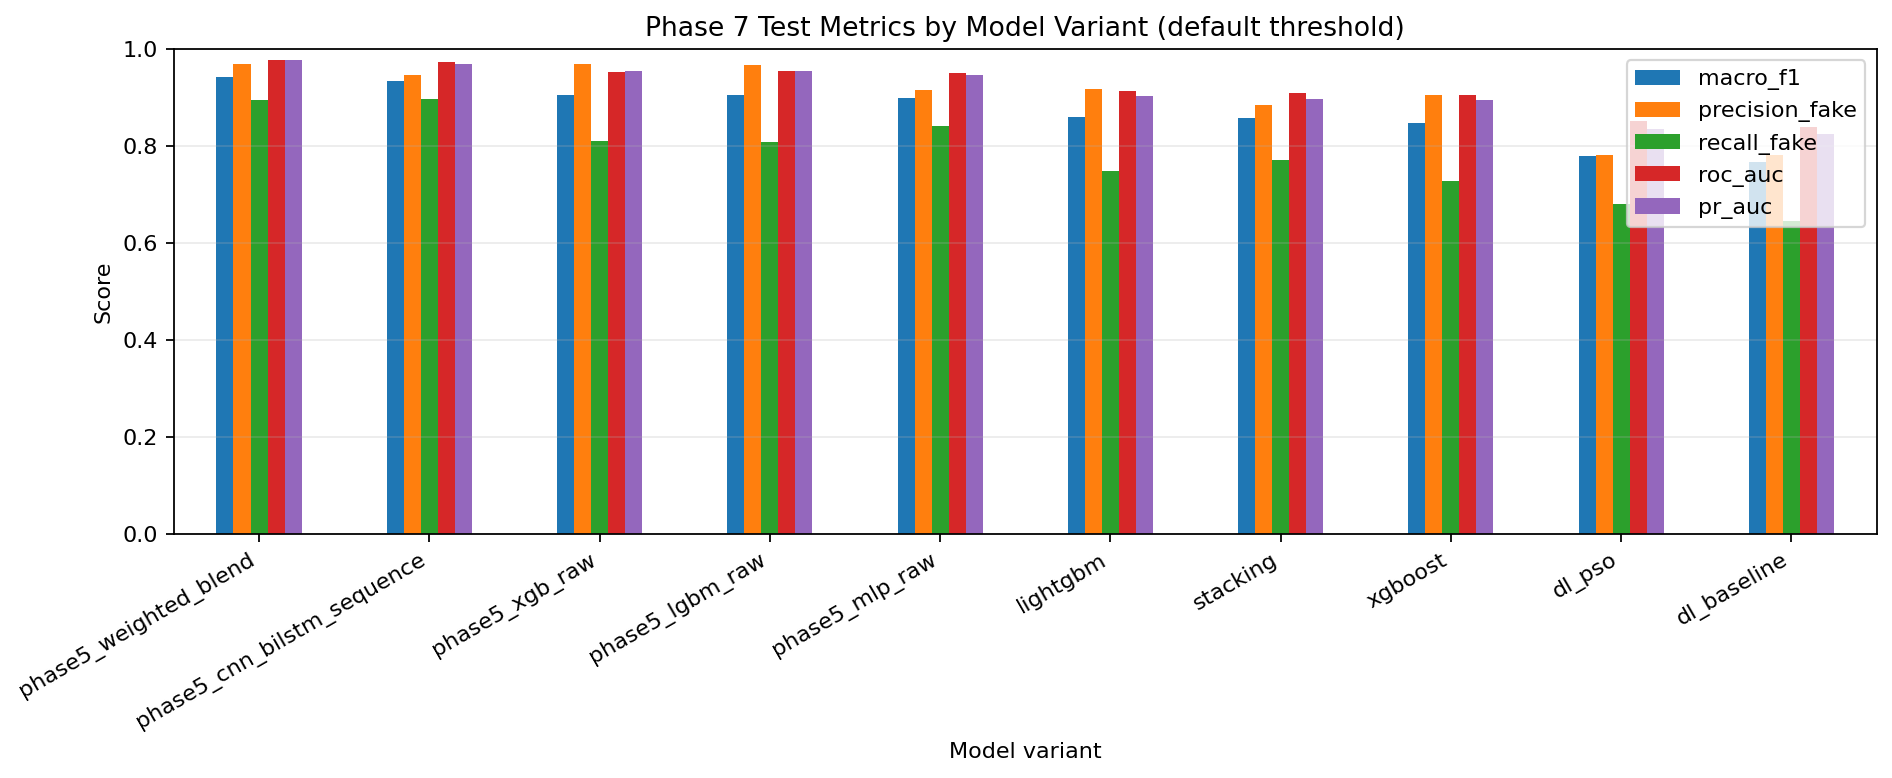

### phase7_target_gap.png

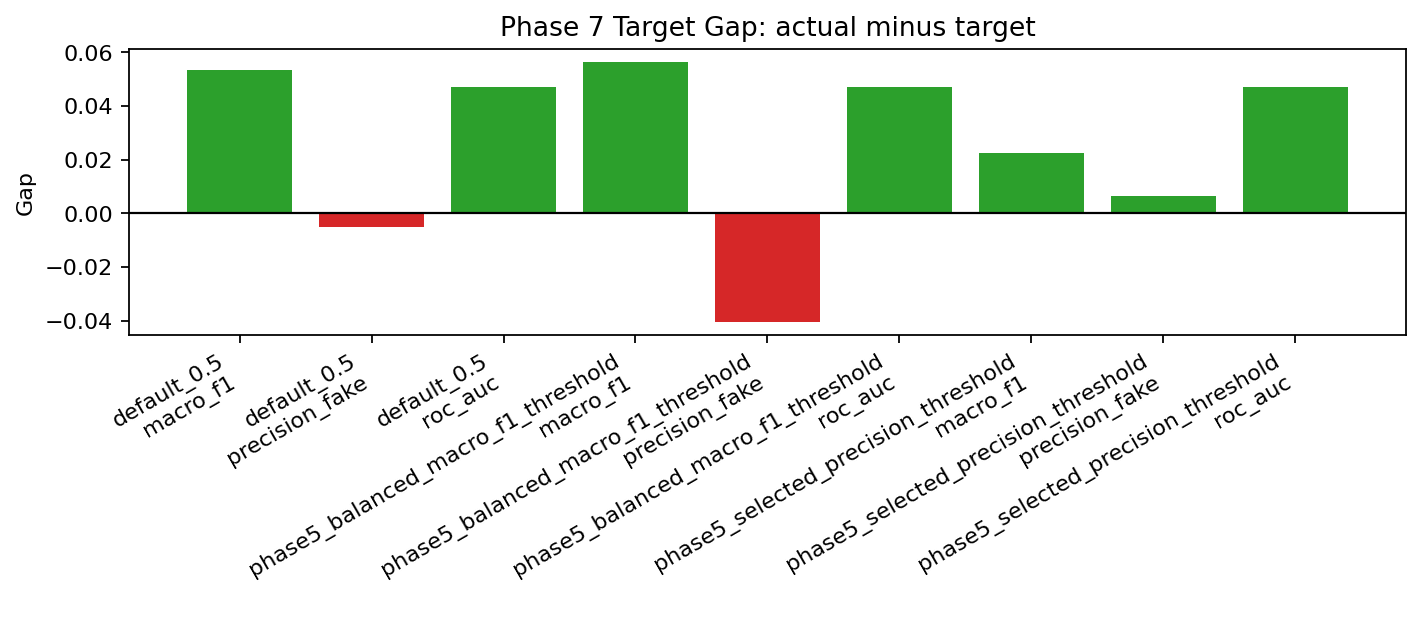

### phase7_cv_summary.png

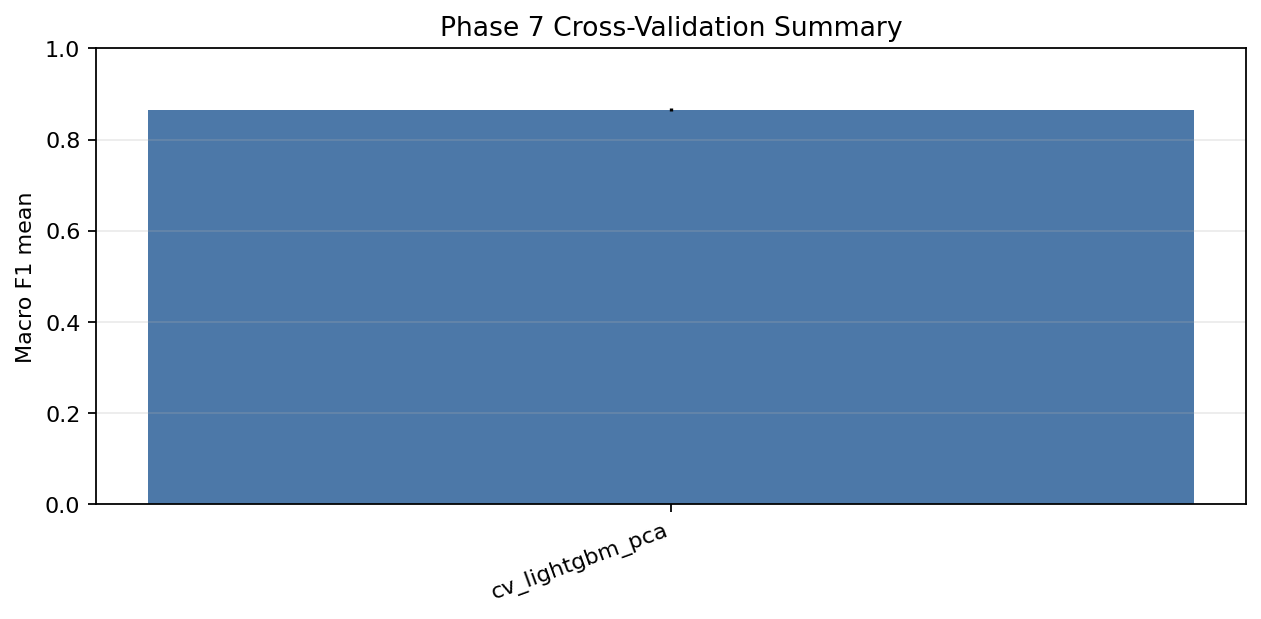

### phase7_ablation_delta.png

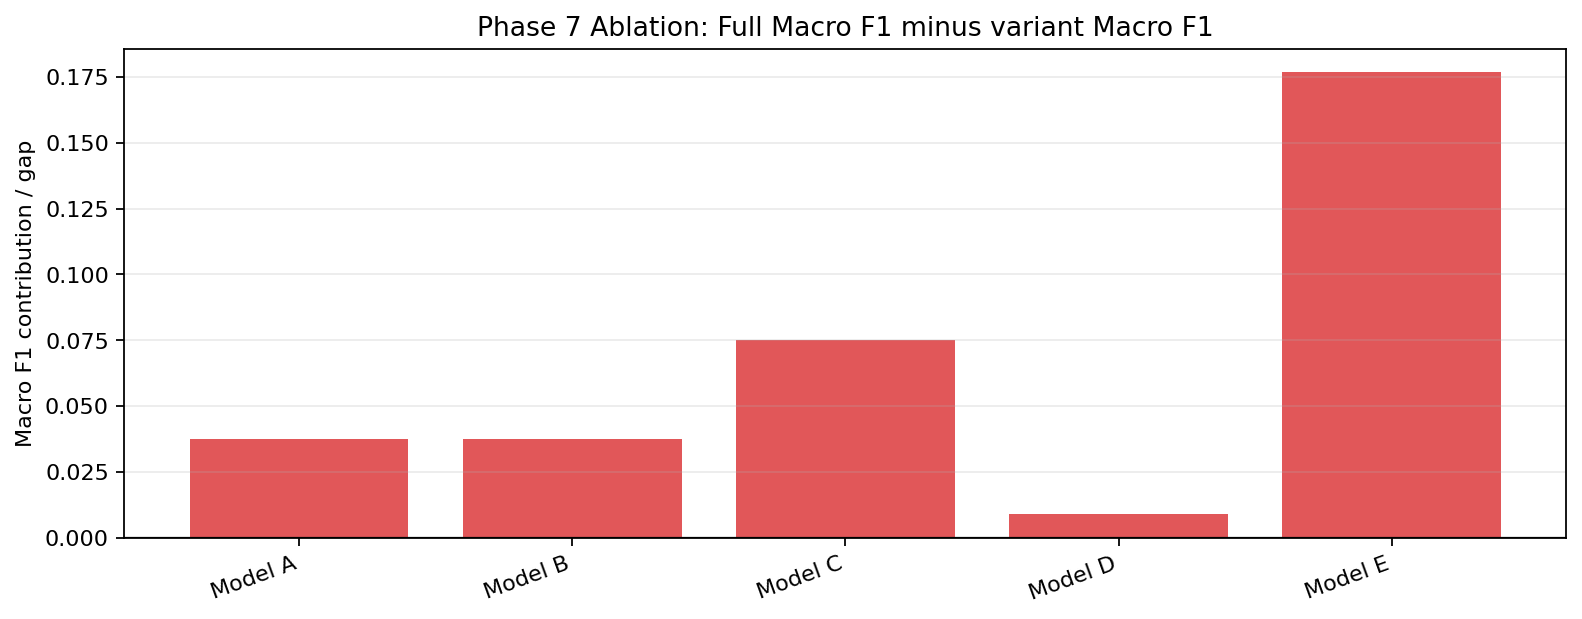

### phase6_robustness_metric_drop.png

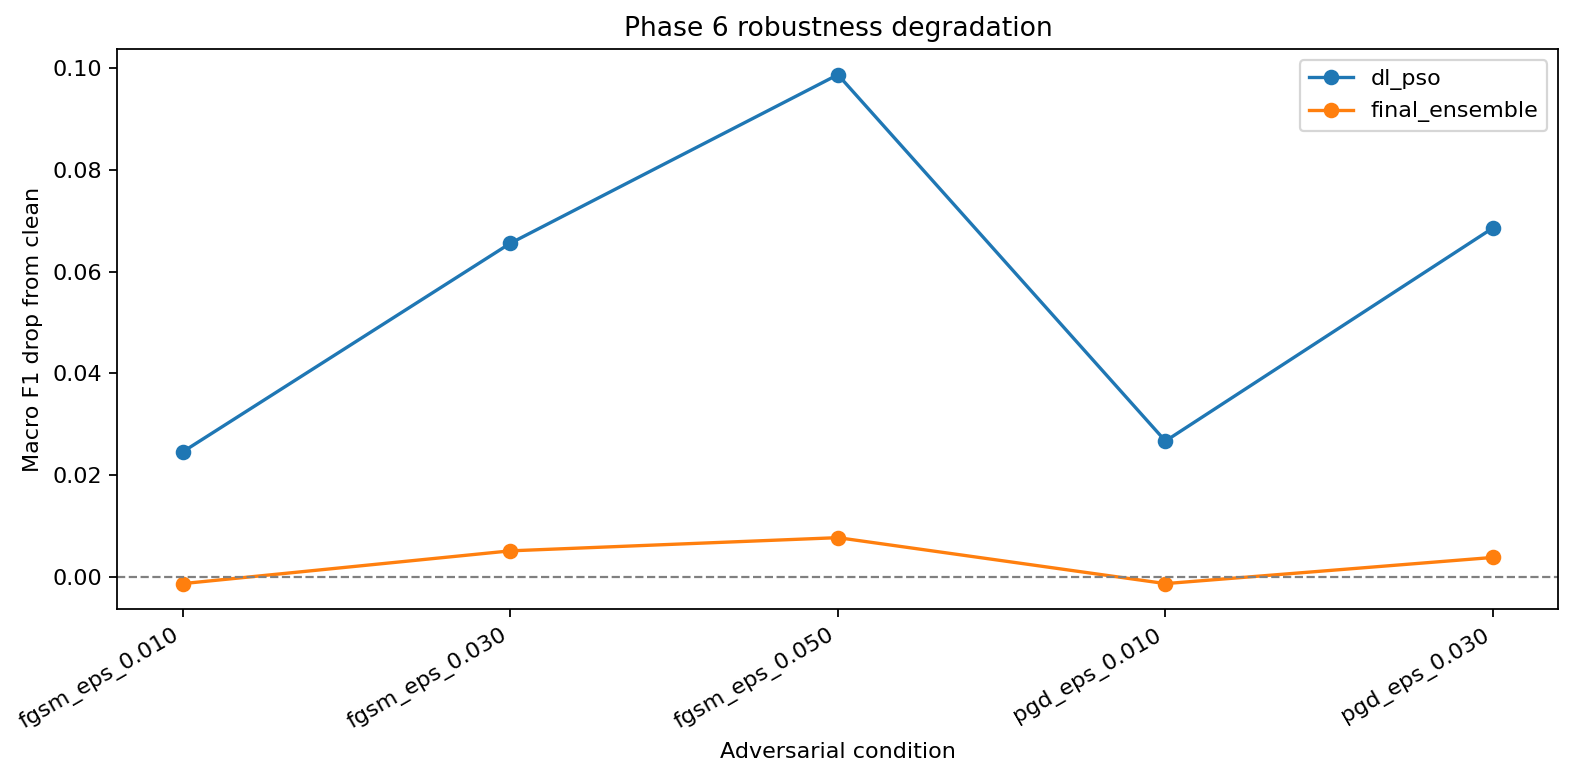

### phase6_shap_top_components.png

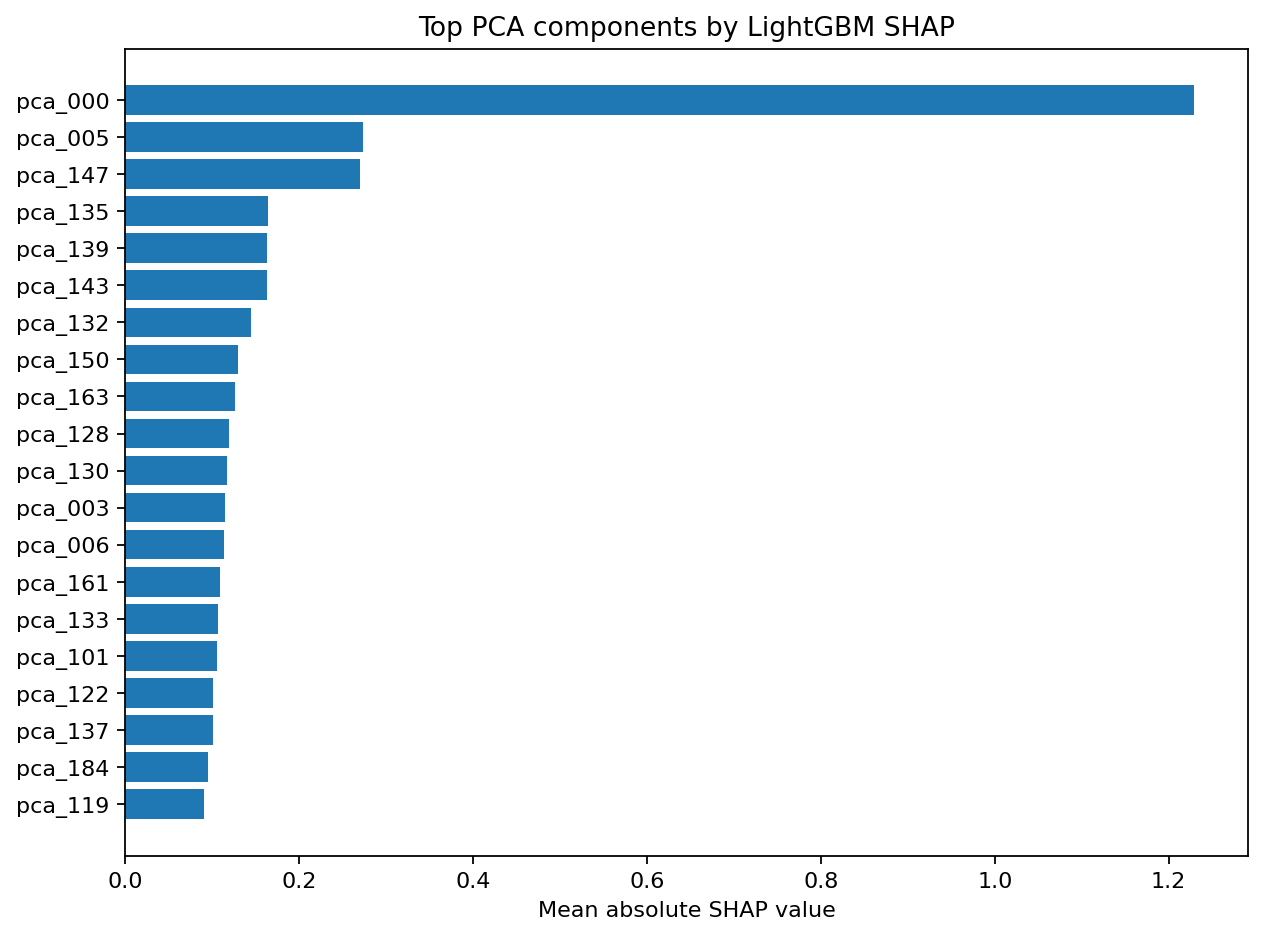

### phase6_shap_summary.png

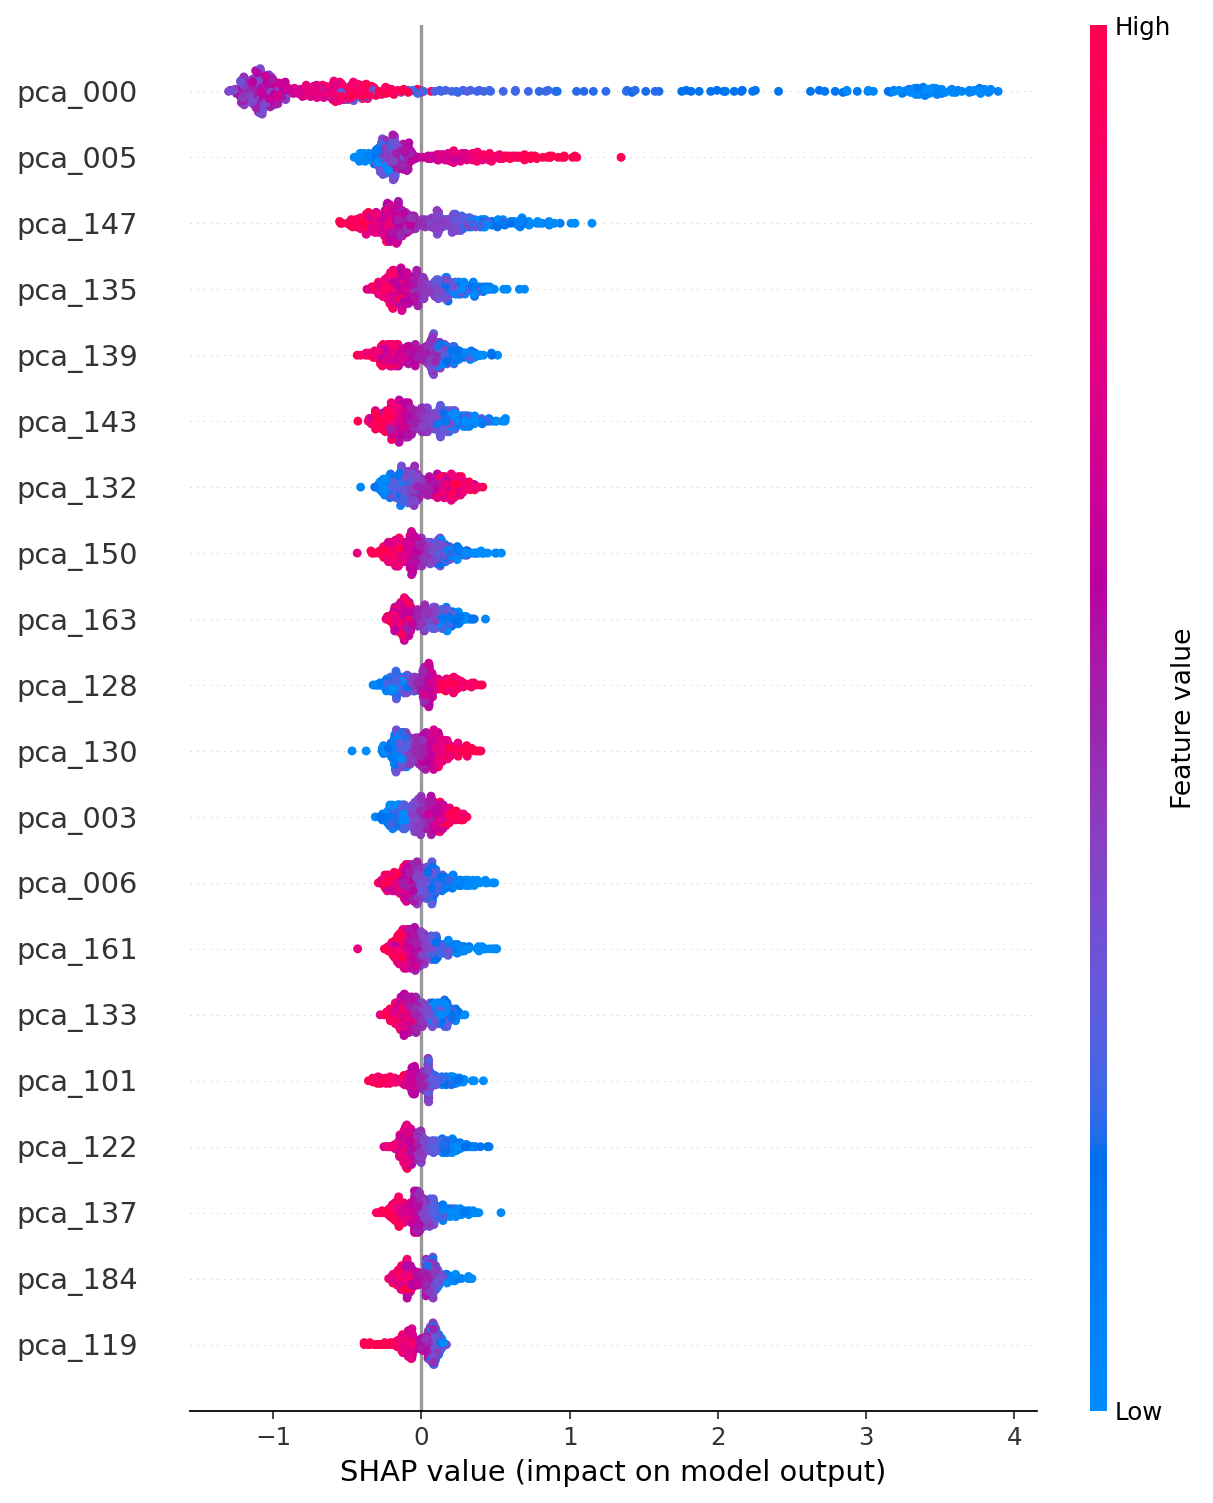

In [11]:
# figure_names = ...: gán giá trị cho biến figure names
figure_names = [
    # 'phase7_final_metrics.png',: thực thi lệnh Python
    'phase7_final_metrics.png',
    # 'phase7_target_gap.png',: thực thi lệnh Python
    'phase7_target_gap.png',
    # 'phase7_cv_summary.png',: tính tổng
    'phase7_cv_summary.png',
    # 'phase7_ablation_delta.png',: thực thi lệnh Python
    'phase7_ablation_delta.png',
    # 'phase6_robustness_metric_drop.png',: thực thi lệnh Python
    'phase6_robustness_metric_drop.png',
    # 'phase6_shap_top_components.png',: thực thi lệnh Python
    'phase6_shap_top_components.png',
    # 'phase6_shap_summary.png',: tính tổng
    'phase6_shap_summary.png',
# ]: đóng khối danh sách
]
# for: vòng lặp — for name in figure_names:
for name in figure_names:
    # path = ...: gán giá trị cho biến path
    path = FIGURE_DIR / name
    # if: điều kiện — if path.exists():
    if path.exists():
        # display(Markdown(f': hiển thị bảng/kết quả trên notebook
        display(Markdown(f'### {name}'))
        # display(Image(filename=str(path))): hiển thị bảng/kết quả trên notebook
        display(Image(filename=str(path)))
    # else: nhánh còn lại của điều kiện
    else:
        # print(f'Missing optional figure: {path}'): in thông tin ra console
        print(f'Missing optional figure: {path}')


## Final checklist

- `reports/final/Phase8_Final_Report.md` generated.
- `reports/final/phase8_artifact_inventory.csv` generated.
- `reports/final/phase8_run_order_checklist.csv` generated.
- `reports/final/phase8_submission_package_manifest.csv` generated.
- `reports/final/phase8_report_summary.csv` generated.
- Target gaps are reported explicitly.
- Model B no-PCA caveat is included.
